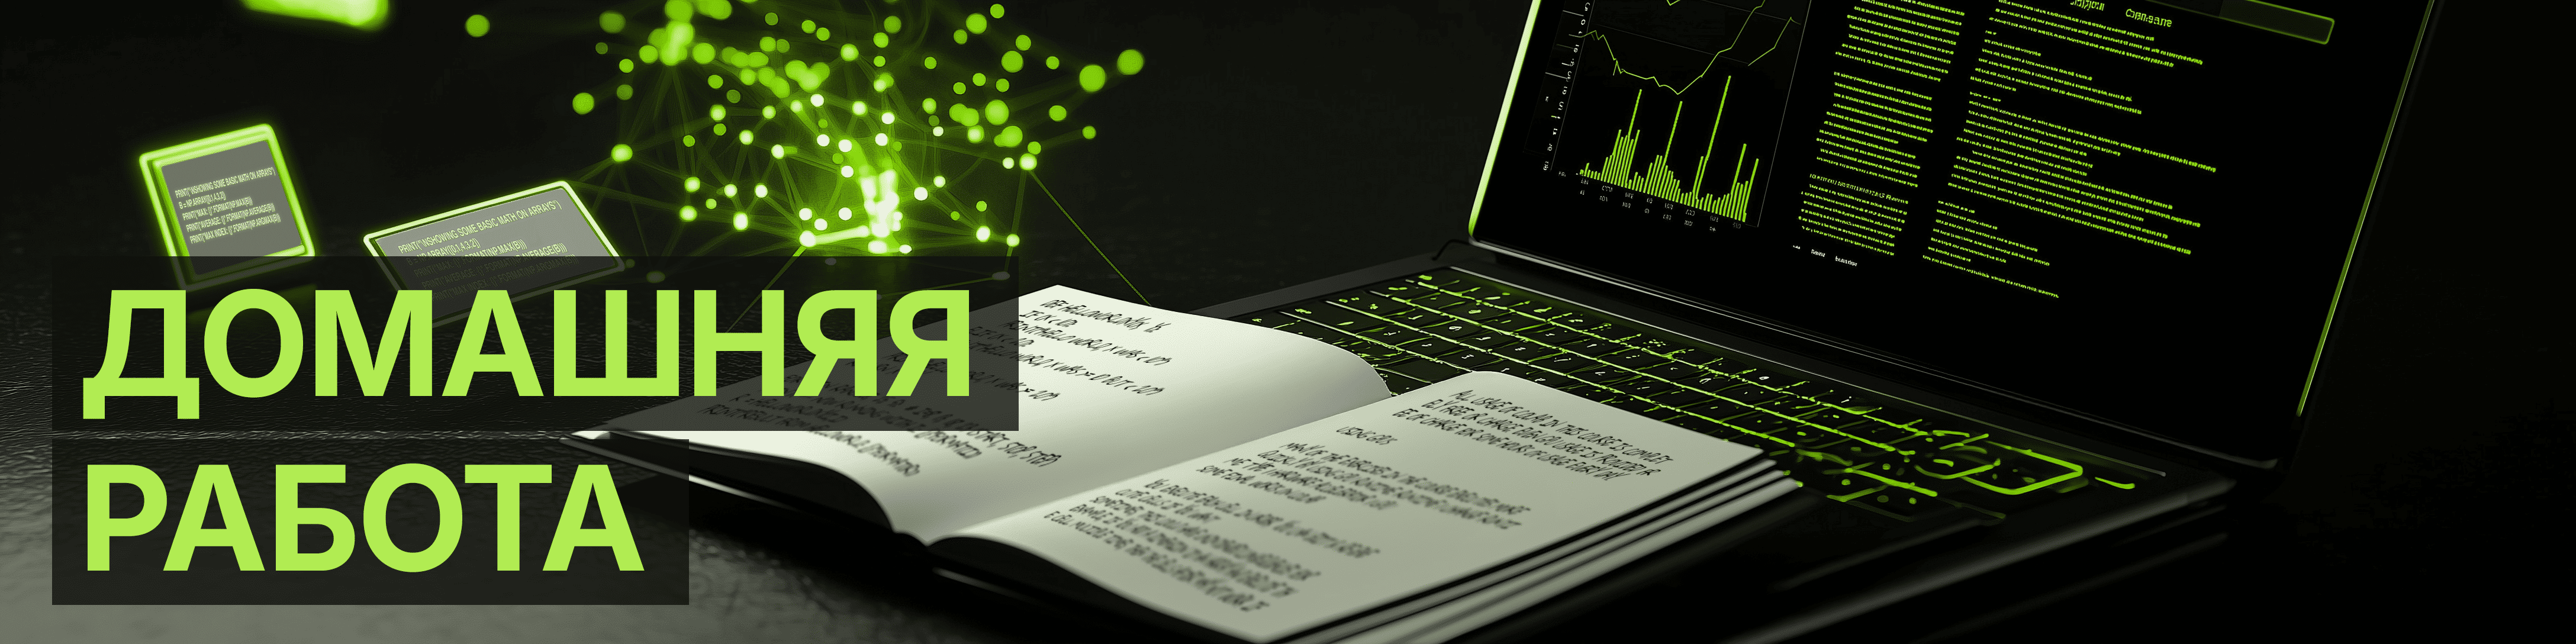

**Навигация по уроку**
1. [Семантическая сегментация изображений](https://colab.research.google.com/drive/10Zl8P7-YLFr9kXdjnvUuXDkruFBSFrlc)
2. [Практическая реализация модели сегментации](https://colab.research.google.com/drive/1yFPXLtKKTQcnOAy6JO3FYHdTbOAGtprR)
3. [Мультиклассовая сегментация](https://colab.research.google.com/drive/1Fy26vjAZPOVTOh8ZLnUYHiev3jD7J4Sh)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:


**Задание 1. На 3 балла:**

1. Ваша задача используя модель и датасет из третей части урока, самостоятельно познакомиться с библиотекой [Albumentations](https://albumentations.ai/) и применить несколько методов аугментации для семантической сегментации снимков с беспилотника.

2. Используйте коллбэк функцию для предварительной остановки процесса обучения. Подумайте: какие параметры для остановки вы применили и почему?


**Задание 2. На 4 балла:**

1. Ваша задача зарегистрироваться на платформе по проведению соревнований в сфере машинного обучения [kaggle](https://www.kaggle.com/).
2. Загрузить датасет с данными о радиографическом ислледовании по COVID-19:

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as op
op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: xloper228
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:07<00:00, 114MB/s] 


3. Обучить U-net подобную архитектуру сегментировать легкие человека на радиографическом снимке. Используйте данные о нормальном состоянии легких в папке `covid19-radiography-database/COVID-19_Radiography_Dataset/Normal`.

4. Отобразите по 10 снимков с оригинальным изображением, оригинальной маской и предсказанной маской.

**Задание 3. На 5 балла:**

1. Самостоятельно изучите модель [U-net++](https://arxiv.org/pdf/1807.10165.pdf). Найдите ее архитектуру, в интернете множество статей с готовой архитектурой на TensorFlow и Keras.
2. Выполните задание 2 для датасета с нормальным состоянием легких используя модель U-net++.


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import os
import glob
import random
import skimage.io
import skimage.transform
import matplotlib.pyplot as plt
import sys

# Конфигурация
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 1 # Полутоновые изображения

BASE_DIR = './covid19-radiography-database/COVID-19_Radiography_Dataset/'

NORMAL_IMG_DIR = os.path.join(BASE_DIR, 'Normal/images')
NORMAL_MASK_DIR = os.path.join(BASE_DIR, 'Normal/masks')

print(f"Поиск изображений в: {NORMAL_IMG_DIR}")
print(f"Поиск масок в: {NORMAL_MASK_DIR}")

In [ ]:
# Загрузка и предварительная обработка данных
def load_data(img_dir, mask_dir, img_size=(IMG_HEIGHT, IMG_WIDTH), max_images=None):
    image_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, '*.png')))

    mask_filenames = {os.path.basename(mf): mf for mf in mask_files}

    valid_image_files = []
    valid_mask_files = []

    for img_f in image_files:
        img_basename = os.path.basename(img_f)
        if img_basename in mask_filenames:
            valid_image_files.append(img_f)
            valid_mask_files.append(mask_filenames[img_basename])

    print(f"Найдено {len(valid_image_files)} изображений и {len(valid_mask_files)} масок с совпадающими именами.")

    if not valid_image_files:
        print(f"Ошибка: Изображения не найдены в {img_dir} или нет совпадающих масок в {mask_dir}.")
        print("Пожалуйста, убедитесь, что ваша директория NORMAL_IMG_DIR содержит изображения, а NORMAL_MASK_DIR - соответствующие маски.")
        print("Пример: Если существует 'Normal/image1.png', то также должна существовать 'Normal/masks/image1.png'.")
        return np.array([]), np.array([])

    if max_images is not None and len(valid_image_files) > max_images:
        valid_image_files = valid_image_files[:max_images]
        valid_mask_files = valid_mask_files[:max_images]
        print(f"Ограничено использование {max_images} изображений и масок.")

    X = np.zeros((len(valid_image_files), img_size[0], img_size[1], IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(valid_image_files), img_size[0], img_size[1], 1), dtype=np.float32)

    for i, (img_path, mask_path) in enumerate(zip(valid_image_files, valid_mask_files)):
        img = skimage.io.imread(img_path, as_gray=True)
        img = skimage.transform.resize(img, (img_size[0], img_size[1]), mode='constant', preserve_range=True)
        X[i, ..., 0] = img / 255.0

        mask = skimage.io.imread(mask_path, as_gray=True)
        mask = skimage.transform.resize(mask, (img_size[0], img_size[1]), mode='constant', preserve_range=True)
        Y[i, ..., 0] = (mask > (0.5 * np.max(mask))).astype(np.float32)

    return X, Y

In [ ]:
# Загружаем данные
if not os.path.exists(NORMAL_MASK_DIR):
    print(f"Ошибка: Директория с масками {NORMAL_MASK_DIR} не существует!")
    print("Пожалуйста, создайте эту директорию и поместите в нее ваши маски сегментации легких.")
    print("Маски должны иметь те же имена файлов, что и изображения в директории 'Normal'.")
    sys.exit("Выход из программы, так как директория масок не найдена.")
else:
    MAX_DATASET_SIZE = 2000
    X_all, Y_all = load_data(NORMAL_IMG_DIR, NORMAL_MASK_DIR, max_images=MAX_DATASET_SIZE)

if X_all.size == 0 or Y_all.size == 0:
    print("Данные не загружены. Пожалуйста, проверьте ваши директории изображений и масок, а также пути.")
    print("Выполнение остановлено, так как нет данных для обучения.")
    sys.exit("Нет данных для обучения.")
else:
    print(f"Данные загружены: форма X_all: {X_all.shape}, форма Y_all: {Y_all.shape}")

    if X_all.shape[0] > 0 and Y_all.shape[0] > 0:
        x_train, x_val, y_train, y_val = train_test_split(X_all, Y_all, test_size=0.1, random_state=42)
        print(f"Обучающие данные: {x_train.shape}, Валидационные данные: {x_val.shape}")
    else:
        print("Недостаточно данных для разделения на обучающую и валидационную выборки.")
        sys.exit("Нет данных для обучения.")

In [ ]:
# Функция потерь и метрики
    def dice_coef(y_true, y_pred, smooth=1.):
        y_true_f = K.flatten(y_true)
        y_pred_f = K.flatten(y_pred)
        intersection = K.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

    def bce_dice_loss(y_true, y_pred):
        return 0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred) - dice_coef(y_true, y_pred)

In [ ]:
# Архитектура модели
    tf.keras.backend.clear_session()
    nb_filter = [32, 64, 128, 256, 512]

    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

    # Этап 1 - Энкодер
    c1 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (inputs)
    c1 = Dropout(0.5) (c1)
    c1 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c1)
    c1 = Dropout(0.5) (c1)
    p1 = MaxPooling2D((2, 2), strides=(2, 2)) (c1)

    c2 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p1)
    c2 = Dropout(0.5) (c2)
    c2 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c2)
    c2 = Dropout(0.5) (c2)
    p2 = MaxPooling2D((2, 2), strides=(2, 2)) (c2)

    # Этап 1.2 (x01)
    up1_2 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up12', padding='same')(c2)
    conv1_2 = concatenate([up1_2, c1], name='merge12', axis=3)
    x01 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_2)
    x01 = Dropout(0.5) (x01)
    x01 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x01)
    x01 = Dropout(0.5) (x01)

    # Этап 2.1 (x20)
    c3_1 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p2)
    c3_1 = Dropout(0.5) (c3_1)
    c3_1 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c3_1)
    c3_1 = Dropout(0.5) (c3_1)
    p3 = MaxPooling2D((2, 2), strides=(2, 2), name='pool3')(c3_1)

    # Этап 2.2 (x11)
    up2_2 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up22', padding='same')(c3_1)
    conv2_2 = concatenate([up2_2, c2], name='merge22', axis=3)
    x11 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_2)
    x11 = Dropout(0.5) (x11)
    x11 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x11)
    x11 = Dropout(0.5) (x11)

    # Этап 1.3 (x02)
    up1_3 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up13', padding='same')(x11)
    conv1_3 = concatenate([up1_3, c1, x01], name='merge13', axis=3)
    x02 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_3)
    x02 = Dropout(0.5) (x02)
    x02 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x02)
    x02 = Dropout(0.5) (x02)

    # Этап 3.1 (x30)
    c4_1 = Conv2D(nb_filter[3], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p3)
    c4_1 = Dropout(0.5) (c4_1)
    c4_1 = Conv2D(nb_filter[3], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c4_1)
    c4_1 = Dropout(0.5) (c4_1)
    p4 = MaxPooling2D((2, 2), strides=(2, 2), name='pool4')(c4_1)

    # Этап 3.2 (x21)
    up3_2 = Conv2DTranspose(nb_filter[2], (2, 2), strides=(2, 2), name='up32', padding='same')(c4_1)
    conv3_2 = concatenate([up3_2, c3_1], name='merge32', axis=3)
    x21 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_2)
    x21 = Dropout(0.5) (x21)
    x21 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x21)
    x21 = Dropout(0.5) (x21)

    # Этап 2.3 (x12)
    up2_3 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up23', padding='same')(x21)
    conv2_3 = concatenate([up2_3, c2, x11], name='merge23', axis=3)
    x12 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_3)
    x12 = Dropout(0.5) (x12)
    x12 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x12)
    x12 = Dropout(0.5) (x12)

    # Этап 1.4 (x03)
    up1_4 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up14', padding='same')(x12)
    conv1_4 = concatenate([up1_4, c1, x01, x02], name='merge14', axis=3)
    x03 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_4)
    x03 = Dropout(0.5) (x03)
    x03 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x03)
    x03 = Dropout(0.5) (x03)

    # Этап 4.1
    c5_1 = Conv2D(nb_filter[4], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (p4)
    c5_1 = Dropout(0.5) (c5_1)
    c5_1 = Conv2D(nb_filter[4], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (c5_1)
    c5_1 = Dropout(0.5) (c5_1)

    # Этап 4.2 (x31)
    up4_2 = Conv2DTranspose(nb_filter[3], (2, 2), strides=(2, 2), name='up42', padding='same')(c5_1)
    conv4_2 = concatenate([up4_2, c4_1], name='merge42', axis=3)
    x31 = Conv2D(nb_filter[3], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv4_2)
    x31 = Dropout(0.5) (x31)
    x31 = Conv2D(nb_filter[3], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x31)
    x31 = Dropout(0.5) (x31)

    # Этап 3.3 (x22)
    up3_3 = Conv2DTranspose(nb_filter[2], (2, 2), strides=(2, 2), name='up33', padding='same')(x31)
    conv3_3 = concatenate([up3_3, c3_1, x21], name='merge33', axis=3)
    x22 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv3_3)
    x22 = Dropout(0.5) (x22)
    x22 = Conv2D(nb_filter[2], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x22)
    x22 = Dropout(0.5) (x22)

    # Этап 2.4 (x13)
    up2_4 = Conv2DTranspose(nb_filter[1], (2, 2), strides=(2, 2), name='up24', padding='same')(x22)
    conv2_4 = concatenate([up2_4, c2, x11, x12], name='merge24', axis=3)
    x13 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv2_4)
    x13 = Dropout(0.5) (x13)
    x13 = Conv2D(nb_filter[1], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x13)
    x13 = Dropout(0.5) (x13)

    # Этап 1.5 (x04)
    up1_5 = Conv2DTranspose(nb_filter[0], (2, 2), strides=(2, 2), name='up15', padding='same')(x13)
    conv1_5 = concatenate([up1_5, c1, x01, x02, x03], name='merge15', axis=3)
    x04 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (conv1_5)
    x04 = Dropout(0.5) (x04)
    x04 = Conv2D(nb_filter[0], (3, 3), activation='elu', kernel_initializer='he_normal', padding='same') (x04)
    x04 = Dropout(0.5) (x04)

    nestnet_output = Conv2D(1, (1, 1), activation='sigmoid', kernel_initializer = 'he_normal', name='output', padding='same')(x04)

    model = Model(inputs=[inputs], outputs=[nestnet_output])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss=bce_dice_loss,
                  metrics=[dice_coef])

In [ ]:
    # Аугментация данных
    data_gen_args = dict(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        shear_range=0.05,
        zoom_range=0.05,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    image_datagen = ImageDataGenerator(**data_gen_args)
    mask_datagen = ImageDataGenerator(**data_gen_args)

    seed = 42
    BATCH_SIZE = 8

    train_image_generator = image_datagen.flow(
        x_train,
        seed=seed,
        batch_size=BATCH_SIZE
    )
    train_mask_generator = mask_datagen.flow(
        y_train,
        seed=seed,
        batch_size=BATCH_SIZE
    )

    def create_combined_generator(img_gen, mask_gen):
        while True:
            img_batch = next(img_gen)
            mask_batch = next(mask_gen)
            yield img_batch, mask_batch

    train_generator = create_combined_generator(train_image_generator, train_mask_generator)

    val_image_datagen = ImageDataGenerator()
    val_mask_datagen = ImageDataGenerator()

    val_generator = create_combined_generator(
        val_image_datagen.flow(x_val, seed=seed, batch_size=BATCH_SIZE),
        val_mask_datagen.flow(y_val, seed=seed, batch_size=BATCH_SIZE)
    )

Поиск изображений в: ./covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
Поиск масок в: ./covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks
Найдено 10192 изображений и 10192 масок с совпадающими именами.
Ограничено использование 2000 изображений и масок.
Данные загружены: форма X_all: (2000, 256, 256, 1), форма Y_all: (2000, 256, 256, 1)
Обучающие данные: (1800, 256, 256, 1), Валидационные данные: (200, 256, 256, 1)
Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 1))
  warnings.warn(msg)


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - dice_coef: 0.4762 - loss: 0.0427
Epoch 1: val_loss improved from inf to 0.19291, saving model to best_lung_unet_plus_plus_model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 172s 452ms/step - dice_coef: 0.4767 - loss: 0.0413 - val_dice_coef: 0.5339 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - dice_coef: 0.7755 - loss: -0.6175
Epoch 2: val_loss did not improve from 0.19291
225/225 ━━━━━━━━━━━━━━━━━━━━ 139s 620ms/step - dice_coef: 0.7757 - loss: -0.6178 - val_dice_coef: 0.0114 - val_loss: 0.6651 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - dice_coef: 0.9012 - loss: -0.8233
Epoch 3: val_loss did not improve from 0.19291
225/225 ━━━━━━━━━━━━━━━━━━━━ 103s 457ms/step - dice_coef: 0.9013 - loss: -0.8235 - val_dice_coef: 7.4924e-05 - val_loss: 1.3540 - learning_rate: 0.0010
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - dice_coef: 0.9417 - loss: -0.8971
Epoch 4: v

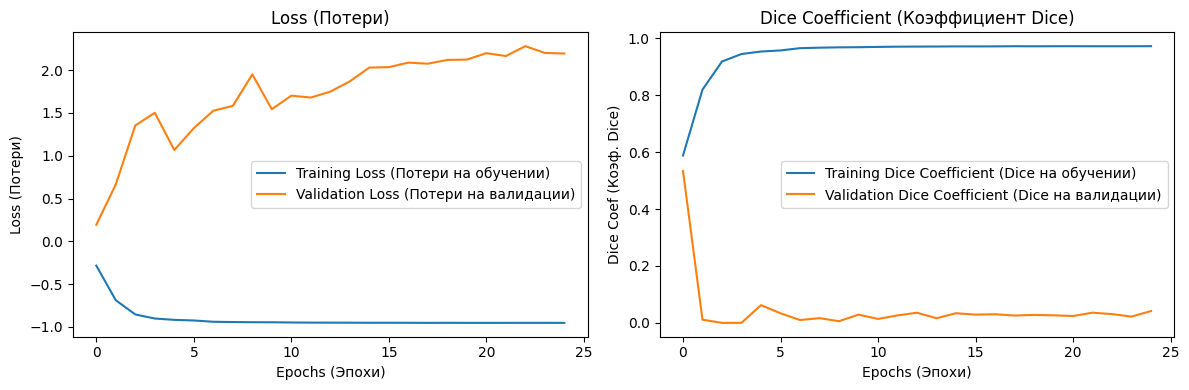

In [ ]:
    # Обучение
    NUM_EPOCHS = 25

    callbacks_list = [
        ModelCheckpoint('best_lung_unet_plus_plus_model.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)
    ]

    if x_train.shape[0] > 0 and y_train.shape[0] > 0:
        history = model.fit(
            train_generator,
            steps_per_epoch=len(x_train) // BATCH_SIZE,
            validation_data=val_generator,
            validation_steps=len(x_val) // BATCH_SIZE,
            epochs=NUM_EPOCHS,
            callbacks=callbacks_list,
            verbose=1
        )

        #Отображение истории обучения
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss (Потери на обучении)')
        plt.plot(history.history['val_loss'], label='Validation Loss (Потери на валидации)')
        plt.title('Loss (Потери)')
        plt.xlabel('Epochs (Эпохи)')
        plt.ylabel('Loss (Потери)')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['dice_coef'], label='Training Dice Coefficient (Dice на обучении)')
        plt.plot(history.history['val_dice_coef'], label='Validation Dice Coefficient (Dice на валидации)')
        plt.title('Dice Coefficient (Коэффициент Dice)')
        plt.xlabel('Epochs (Эпохи)')
        plt.ylabel('Dice Coef (Коэф. Dice)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Предсказание и отображение
        model.load_weights('best_lung_unet_plus_plus_model.keras')

Поиск тестовых изображений в: ./covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images
Поиск тестовых масок в: ./covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/masks
Найдено 10192 изображений и 10192 масок с совпадающими именами.
Ограничено использование 500 изображений и масок для тестирования.
Тестовые данные загружены: форма X_test_all: (500, 256, 256, 1), форма Y_test_all: (500, 256, 256, 1)
Фактические тестовые данные: (100, 256, 256, 1), (100, 256, 256, 1)
Модель 'best_lung_unet_plus_plus_model.keras' успешно загружена.

Оценка модели на тестовых данных...
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - dice_coef: 0.5168 - loss: 0.2570
Потери на тесте (Test Loss): 0.2547
Коэффициент Дайса на тесте (Test Dice Coefficient): 0.5131

Визуализация предсказаний на тестовых данных...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41

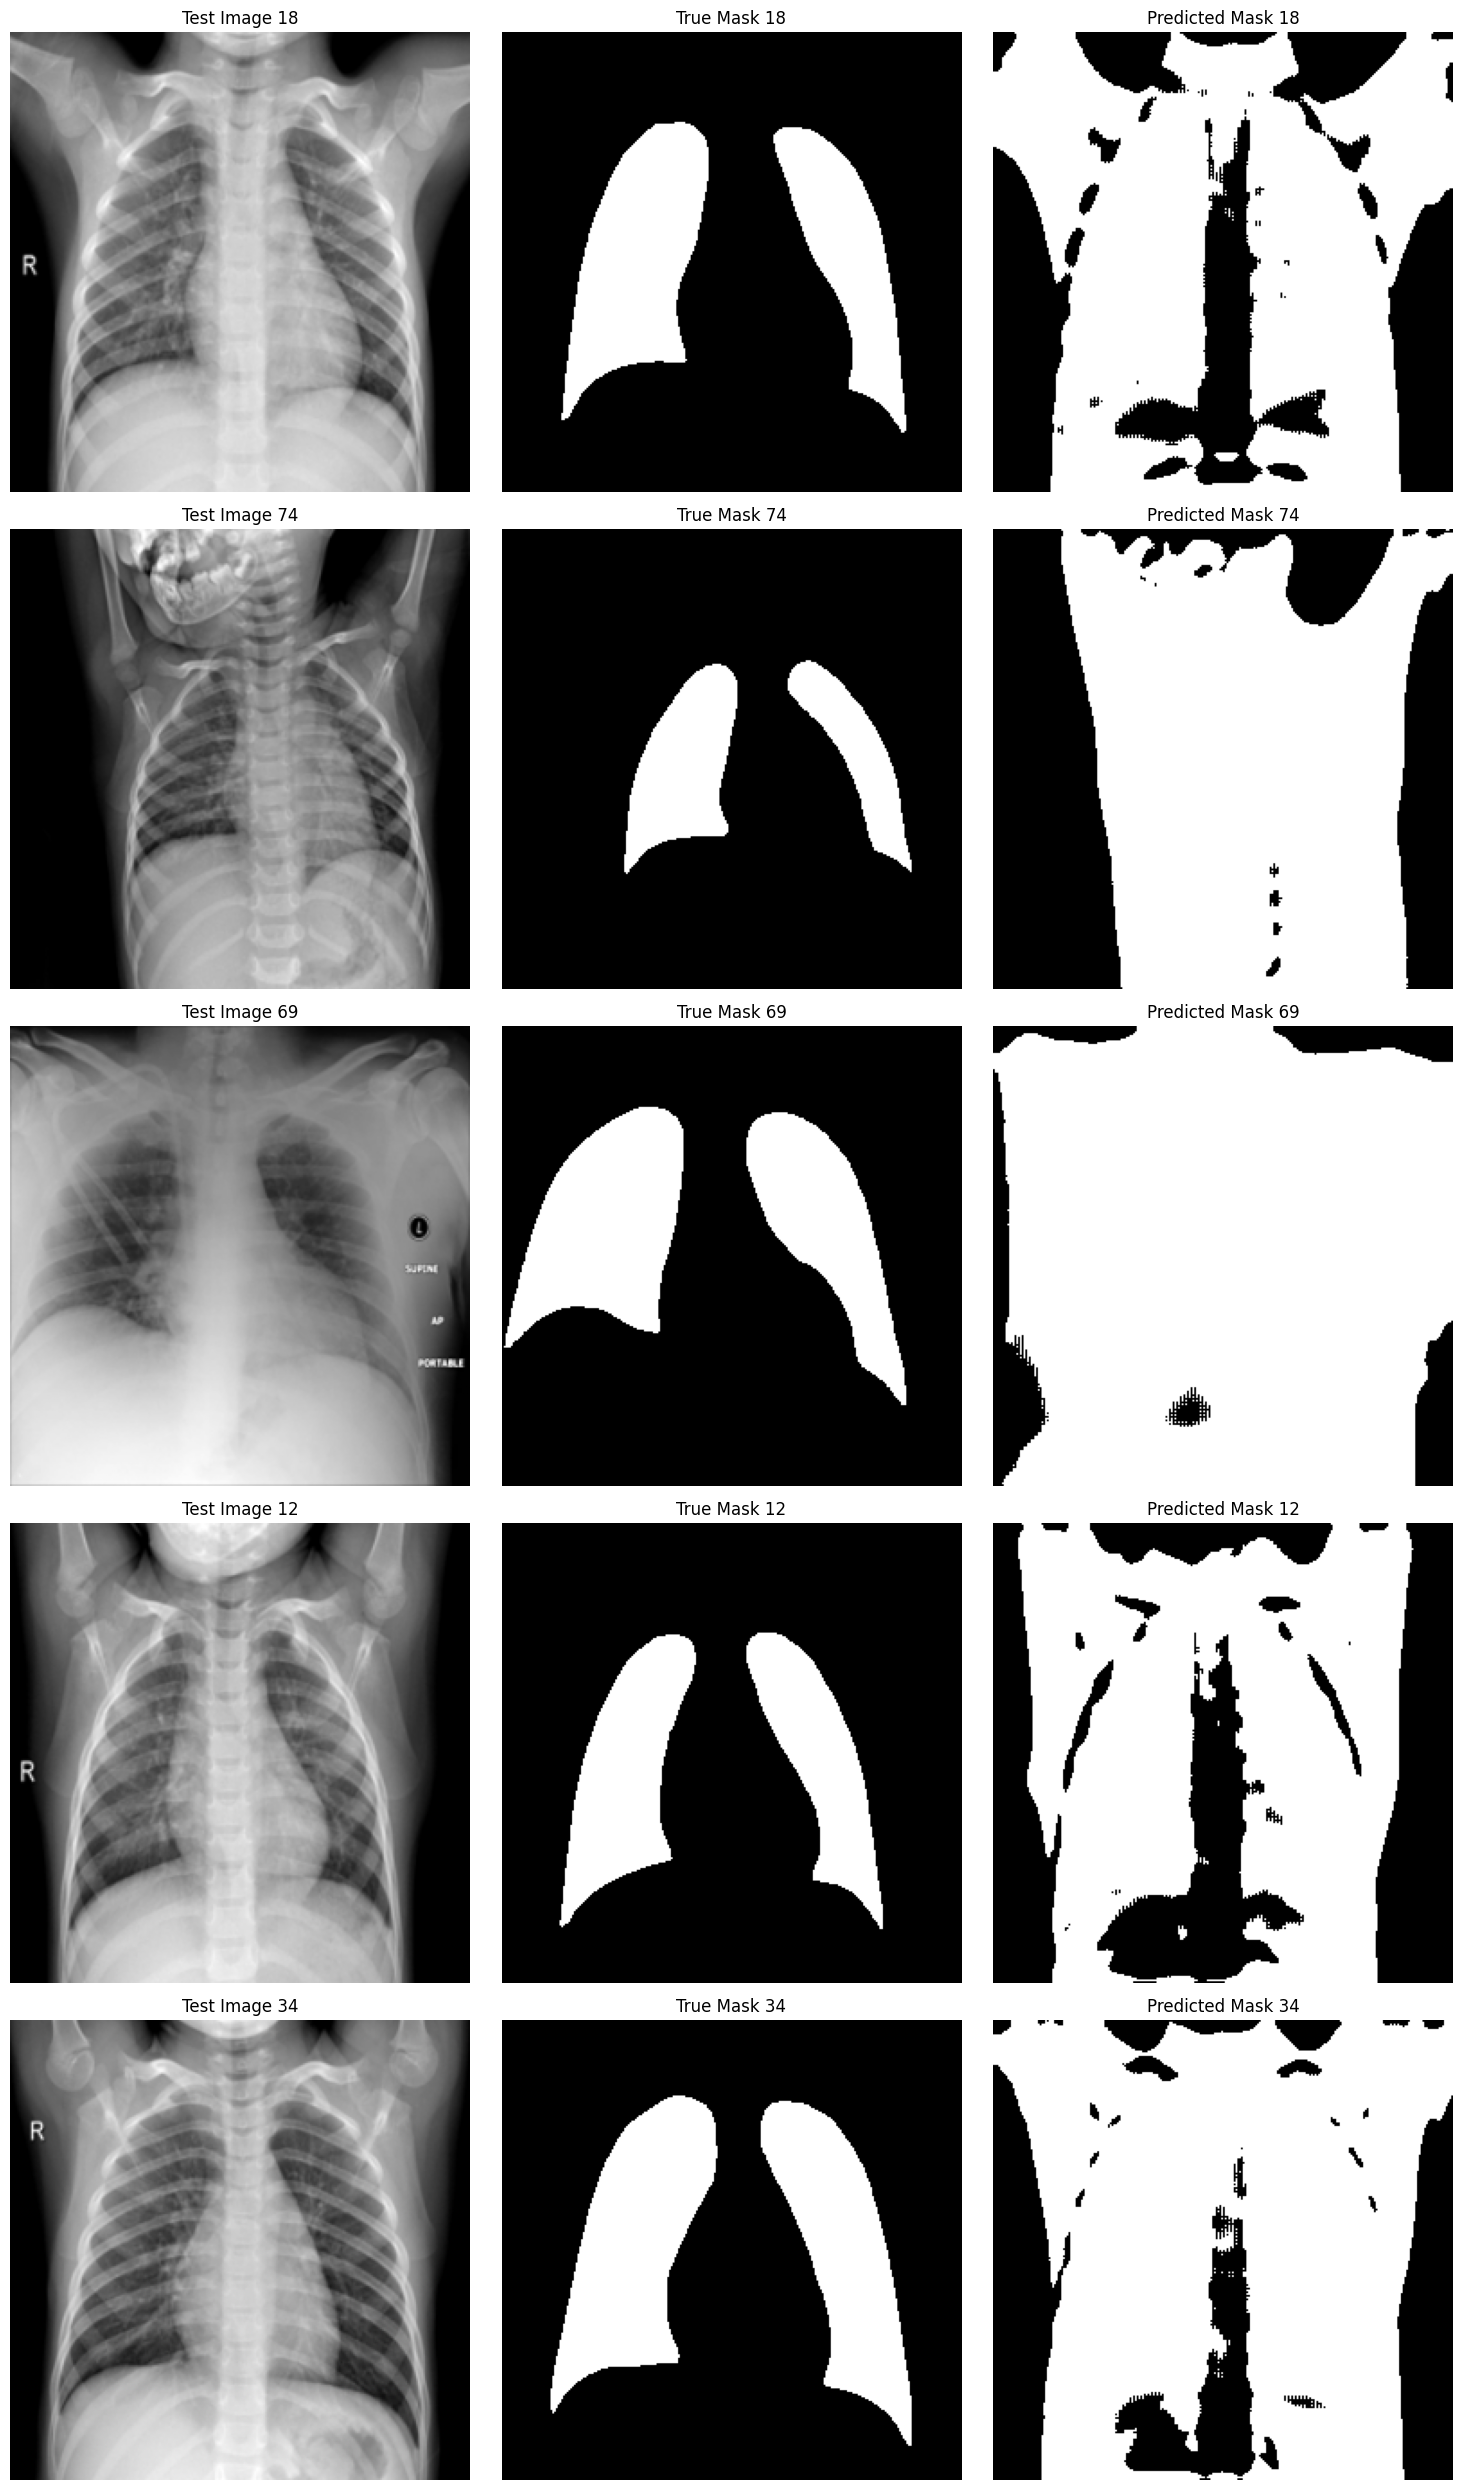

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

import numpy as np
import os
import glob
import skimage.io
import skimage.transform
import matplotlib.pyplot as plt
import sys

IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 1

# Пути к данным для тестирования
BASE_DIR = './covid19-radiography-database/COVID-19_Radiography_Dataset/'
TEST_IMG_DIR = os.path.join(BASE_DIR, 'Normal/images')
TEST_MASK_DIR = os.path.join(BASE_DIR, 'Normal/masks')

# Название сохраненной модели
MODEL_PATH = 'best_lung_unet_plus_plus_model.keras'

print(f"Поиск тестовых изображений в: {TEST_IMG_DIR}")
print(f"Поиск тестовых масок в: {TEST_MASK_DIR}")

def load_data(img_dir, mask_dir, img_size=(IMG_HEIGHT, IMG_WIDTH), max_images=None):
    image_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, '*.png')))

    mask_filenames = {os.path.basename(mf): mf for mf in mask_files}

    valid_image_files = []
    valid_mask_files = []

    for img_f in image_files:
        img_basename = os.path.basename(img_f)
        if img_basename in mask_filenames:
            valid_image_files.append(img_f)
            valid_mask_files.append(mask_filenames[img_basename])

    print(f"Найдено {len(valid_image_files)} изображений и {len(valid_mask_files)} масок с совпадающими именами.")

    if not valid_image_files:
        print(f"Ошибка: Изображения не найдены в {img_dir} или нет совпадающих масок в {mask_dir}.")
        return np.array([]), np.array([])

    if max_images is not None and len(valid_image_files) > max_images:
        valid_image_files = valid_image_files[:max_images]
        valid_mask_files = valid_mask_files[:max_images]
        print(f"Ограничено использование {max_images} изображений и масок для тестирования.")

    X = np.zeros((len(valid_image_files), img_size[0], img_size[1], IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(valid_image_files), img_size[0], img_size[1], 1), dtype=np.float32)

    for i, (img_path, mask_path) in enumerate(zip(valid_image_files, valid_mask_files)):
        img = skimage.io.imread(img_path, as_gray=True)
        img = skimage.transform.resize(img, (img_size[0], img_size[1]), mode='constant', preserve_range=True)
        X[i, ..., 0] = img / 255.0

        mask = skimage.io.imread(mask_path, as_gray=True)
        mask = skimage.transform.resize(mask, (img_size[0], img_size[1]), mode='constant', preserve_range=True)
        Y[i, ..., 0] = (mask > (0.5 * np.max(mask))).astype(np.float32)

    return X, Y

def dice_coef(y_true, y_pred, smooth=1.):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return 0.5 * tf.keras.losses.binary_crossentropy(y_true, y_pred) - dice_coef(y_true, y_pred)

# Загрузка тестовых данных
MAX_TEST_DATASET_SIZE = 500 # Ограничиваем количество тестовых изображений
X_test_all, Y_test_all = load_data(TEST_IMG_DIR, TEST_MASK_DIR, max_images=MAX_TEST_DATASET_SIZE)

if X_test_all.size == 0 or Y_test_all.size == 0:
    print("Не удалось загрузить тестовые данные. Проверьте пути и наличие файлов.")
    sys.exit("Выход из программы, так как нет тестовых данных.")
else:
    print(f"Тестовые данные загружены: форма X_test_all: {X_test_all.shape}, форма Y_test_all: {Y_test_all.shape}")
    _, x_test, _, y_test = train_test_split(X_test_all, Y_test_all, test_size=0.2, random_state=123)
    print(f"Фактические тестовые данные: {x_test.shape}, {y_test.shape}")


# Загрузка обученной модели
try:
    model = load_model(MODEL_PATH, custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef})
    print(f"Модель '{MODEL_PATH}' успешно загружена.")
except Exception as e:
    print(f"Ошибка загрузки модели: {e}")
    print("Убедитесь, что файл модели существует и путь верен.")
    sys.exit("Не удалось загрузить модель.")

# Оценка модели на тестовых данных
print("\nОценка модели на тестовых данных...")
test_results = model.evaluate(x_test, y_test, verbose=1)

print(f"Потери на тесте (Test Loss): {test_results[0]:.4f}")
print(f"Коэффициент Дайса на тесте (Test Dice Coefficient): {test_results[1]:.4f}")

print("\nВизуализация предсказаний на тестовых данных...")

num_visualize = 5 # Количество изображений для визуализации
if len(x_test) < num_visualize:
    num_visualize = len(x_test)

if num_visualize > 0:
    # Случайный выбор индексов
    random_indices = random.sample(range(len(x_test)), num_visualize)

    plt.figure(figsize=(15, 5 * num_visualize))
    for i, idx in enumerate(random_indices):
        img = x_test[idx]
        true_mask = y_test[idx]

        predicted_mask = model.predict(np.expand_dims(img, axis=0))[0]

        plt.subplot(num_visualize, 3, i * 3 + 1)
        plt.imshow(img[...,0], cmap='gray')
        plt.title(f"Test Image {idx+1}")
        plt.axis('off')

        plt.subplot(num_visualize, 3, i * 3 + 2)
        plt.imshow(true_mask[...,0], cmap='gray')
        plt.title(f"True Mask {idx+1}")
        plt.axis('off')

        plt.subplot(num_visualize, 3, i * 3 + 3)
        plt.imshow(predicted_mask[...,0] > 0.5, cmap='gray')
        plt.title(f"Predicted Mask {idx+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно тестовых образцов для визуализации.")